# Polygon area vs. `boundary_max_deviation_um`

Follow-up to the `simplify_tol_um` -> `boundary_max_deviation_um` rename
(`src/MERci/acquisition/mosaic.py`'s `segment_mosaic_tissue`): that
parameter is a Shapely `Polygon.simplify()` Douglas-Peucker tolerance, not
a fixed output segment length. This notebook makes that concrete by
resegmenting the same real mosaic canvas at a range of tolerances
(`[0.1, 0.5, 1, 2, 4, 8, 16, 24]` um) and plotting how the traced tissue
polygon's own area responds -- every other `segment_mosaic_tissue`
parameter held fixed, so the sweep isolates this one knob.


## 1 — Setup


In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as before_imaging/{regular,multi_z}/ -- see CLAUDE.md.
MERCI_DIR  = Path(os.getcwd()).parent.parent.parent   # MERci/
SAMPLE_DIR = MERCI_DIR.parent                  # this repo's own sandbox experiment
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.acquisition.mosaic import segment_mosaic_tissue, load_mosaic_canvas
from MERci.visualization import get_merci_figures_dir

NOTEBOOK_NAME = "sweep_boundary_max_deviation_vs_polygon_area"
CACHE_DIR = SAMPLE_DIR / "analysis" / "cache" / NOTEBOOK_NAME
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = get_merci_figures_dir(SAMPLE_DIR, "tests", NOTEBOOK_NAME, subfolder="create_positions")

print(f"MERCI_DIR : {MERCI_DIR}")
print(f"SAMPLE_DIR: {SAMPLE_DIR}")


MERCI_DIR : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci
SAMPLE_DIR: /n/home06/lsepulvedaduran/251225_LT027_saving_time


## 2 — Load the bundled example canvas + baseline segmentation params

Same real, mosaic-derived canvas (`LT066_sample_01/merfish`, bundled as
`MERci/data/mosaic_canvas_examples/lineage_tracing/canvas.npz`) and the
same `SAFE_PARAMS` baseline already vetted in
`01_compare_fov_coverage_constraint.ipynb` (this same directory) --
`boundary_max_deviation_um` is the only parameter swept below.


In [2]:
canvas = load_mosaic_canvas(MERCI_DIR / "data" / "mosaic_canvas_examples" / "lineage_tracing" / "canvas.npz")
print(f"Canvas: {canvas.image.shape[1]}x{canvas.image.shape[0]} px at {canvas.pixel_size_um:.2f} um/px")

# Same baseline as 01_compare_fov_coverage_constraint.ipynb's SAFE_PARAMS --
# boundary_max_deviation_um is overridden per sweep value below.
BASE_PARAMS = dict(threshold=400, smooth_sigma_um=10.0, close_radius_um=50.0, open_radius_um=15.0,
                    margin_um=25.0, min_tissue_area_um2=4_000_000.0, min_hole_area_um2=12_000.0,
                    min_island_area_um2=50_000.0)

DEVIATION_VALUES_UM = [0.1, 0.5, 1, 2, 4, 8, 16, 24]


Canvas: 1840x1839 px at 5.00 um/px


## 3 — Segment at every `boundary_max_deviation_um`, cache the result


In [3]:
SWEEP_CSV = CACHE_DIR / "boundary_max_deviation_sweep.csv"

if SWEEP_CSV.exists():
    sweep_df = pd.read_csv(SWEEP_CSV)
    print(f"Loaded cached {SWEEP_CSV} ({len(sweep_df)} rows).")
else:
    rows = []
    for dev_um in DEVIATION_VALUES_UM:
        seg = segment_mosaic_tissue(canvas, boundary_max_deviation_um=dev_um, **BASE_PARAMS)
        tissue_area_um2 = sum(p.area for p in seg.tissue_polygons)
        hole_area_um2 = sum(p.area for p in seg.hole_polygons)
        n_vertices = sum(len(p.exterior.coords) for p in seg.tissue_polygons)
        rows.append({
            "boundary_max_deviation_um": dev_um,
            "n_tissue_pieces": len(seg.tissue_polygons),
            "tissue_area_um2": tissue_area_um2,
            "n_holes": len(seg.hole_polygons),
            "hole_area_um2": hole_area_um2,
            "net_area_um2": tissue_area_um2 - hole_area_um2,
            "n_vertices": n_vertices,
        })
        print(f"boundary_max_deviation_um={dev_um:5.1f}: "
              f"tissue_area={tissue_area_um2/1e6:.4f} mm^2, "
              f"n_vertices={n_vertices}, n_holes={len(seg.hole_polygons)}")
    sweep_df = pd.DataFrame(rows)
    sweep_df.to_csv(SWEEP_CSV, index=False)
    print(f"Cached {SWEEP_CSV}.")

sweep_df


boundary_max_deviation_um=  0.1: tissue_area=35.5950 mm^2, n_vertices=3554, n_holes=12


boundary_max_deviation_um=  0.5: tissue_area=35.5950 mm^2, n_vertices=3554, n_holes=12


boundary_max_deviation_um=  1.0: tissue_area=35.5950 mm^2, n_vertices=3554, n_holes=12


boundary_max_deviation_um=  2.0: tissue_area=35.5949 mm^2, n_vertices=2563, n_holes=12


boundary_max_deviation_um=  4.0: tissue_area=35.5941 mm^2, n_vertices=803, n_holes=12


boundary_max_deviation_um=  8.0: tissue_area=35.5847 mm^2, n_vertices=460, n_holes=12


boundary_max_deviation_um= 16.0: tissue_area=35.5706 mm^2, n_vertices=252, n_holes=12


boundary_max_deviation_um= 24.0: tissue_area=35.5688 mm^2, n_vertices=185, n_holes=12
Cached /n/home06/lsepulvedaduran/251225_LT027_saving_time/analysis/cache/sweep_boundary_max_deviation_vs_polygon_area/boundary_max_deviation_sweep.csv.


,boundary_max_deviation_um,n_tissue_pieces,tissue_area_um2,n_holes,hole_area_um2,net_area_um2,n_vertices
0,0.1,1,35594962.5,12,3493712.50,32101250.00,3554
1,0.5,1,35594962.5,12,3493712.50,32101250.00,3554
2,1.0,1,35594962.5,12,3493712.50,32101250.00,3554
3,2.0,1,35594850.0,12,3493656.25,32101193.75,2563
4,4.0,1,35594112.5,12,3495075.00,32099037.50,803
5,8.0,1,35584712.5,12,3494568.75,32090143.75,460
6,16.0,1,35570612.5,12,3489968.75,32080643.75,252
7,24.0,1,35568800.0,12,3489512.50,32079287.50,185


## 4 — Polygon area vs. `boundary_max_deviation_um`


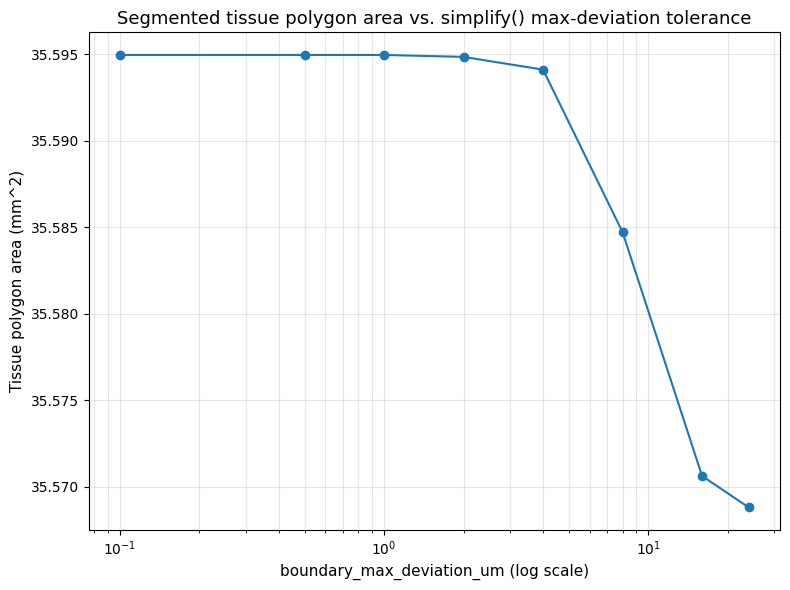

Saved: /n/home06/lsepulvedaduran/251225_LT027_saving_time/figures/MERci/tests/create_positions/sweep_boundary_max_deviation_vs_polygon_area/06_boundary_max_deviation_vs_polygon_area.png


In [4]:
PLOT_TITLE_FONTSIZE, PLOT_LABEL_FONTSIZE = 13, 11
PLOT_TICK_FONTSIZE = 10

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(sweep_df["boundary_max_deviation_um"], sweep_df["tissue_area_um2"] / 1e6, "o-", color="tab:blue")
ax.set_xscale("log")
ax.set_xlabel("boundary_max_deviation_um (log scale)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_ylabel("Tissue polygon area (mm^2)", fontsize=PLOT_LABEL_FONTSIZE)
ax.set_title("Segmented tissue polygon area vs. simplify() max-deviation tolerance", fontsize=PLOT_TITLE_FONTSIZE)
ax.tick_params(axis="both", labelsize=PLOT_TICK_FONTSIZE)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_boundary_max_deviation_vs_polygon_area.png", dpi=150)
plt.show()
print(f"Saved: {FIG_DIR / '06_boundary_max_deviation_vs_polygon_area.png'}")


## 5 — Takeaways

- **Area is nearly flat across the whole sweep**: 35.5950 mm^2 at
  `boundary_max_deviation_um=0.1` down to 35.5688 mm^2 at `=24.0` -- a
  0.073% change over a 240x range of the tolerance. Vertex count, by
  contrast, drops from 3554 to 185 (a 19x reduction) over the same range.
- **Confirms the max-deviation semantics directly**: if
  `boundary_max_deviation_um` set a fixed segment length, coarsening it
  20x+ would reshape the polygon and move its area substantially. Instead
  the traced boundary stays within a `boundary_max_deviation_um`-sized
  band of the same raw contour at every setting, so area barely moves --
  only how many vertices are spent describing that same band changes.
- The area does drift monotonically downward as the tolerance grows
  (visible on the plot's tight y-axis) -- expected for `preserve_topology
  =True` simplification of this mostly-convex-out tissue outline, but two
  orders of magnitude smaller an effect than the vertex-count change.
